# Problema 2 – Regresión: Estimación de Edad a partir de Imágenes Faciales
### Universidad EAFIT | Introducción a la IA – 2026-01

---

## Descripción del Problema

**Dataset:** Faces Age Detection – [Kaggle: arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)

El objetivo es entrenar una **Red Neuronal Convolucional (CNN)** que, dada una imagen facial, estime la **edad** de la persona como valor continuo.

### ¿Por qué es un problema de Regresión?

La variable objetivo (edad) es un **número continuo** (ej. 23, 47, 61). A diferencia de la clasificación —donde la salida es una categoría discreta—, aquí predecimos un valor real. Por ello:
- La capa de salida tiene **1 neurona sin función de activación** (activación lineal).
- La función de pérdida es **MAE / MSE / Huber Loss**, no entropía cruzada.
- Las métricas son **MAE, RMSE y R²**, no accuracy.

### Protocolo de adquisición del dataset

El dataset proviene de **UTKFace**: más de 20 000 imágenes faciales con anotaciones de edad (0–116), género y etnia, recolectadas de internet con diversidad de iluminación, poses y fondos. Las etiquetas fueron verificadas manualmente.

Nombre de archivo: `[age]_[gender]_[race]_[timestamp].jpg` → extraemos la **edad** del nombre del archivo.

---
## 0. Configuración del Entorno

Importamos las librerías y configuramos el dispositivo de cómputo.

**PyTorch** construye y entrena la CNN. **torchvision** provee transformaciones de imagen estándar. **sklearn** nos da las métricas de regresión.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os, re

# --- Reproducibilidad ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Dispositivo ---
# PyTorch corre en GPU (NVIDIA CUDA) si está disponible; si no, usa CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cpu


---
## 1. Carga del Dataset

El dataset real es **UTKFace** ubicado en `archive/faces_02/part3/`. Las imágenes tienen el nombre de archivo codificado como:

```
[age]_[gender]_[race]_[timestamp].jpg
```

Extraemos la **edad directamente del nombre del archivo** — esto nos da un target continuo real (ej. 10, 23, 65), que es exactamente lo que necesitamos para regresión.

In [5]:
DATA_DIR = Path('archive/faces_02/part3')

records = []
for img_path in DATA_DIR.glob('*.jpg'):
    match = re.match(r'^(\d+)_', img_path.name)
    if match:
        age = int(match.group(1))
        records.append({'path': str(img_path), 'age': age})

df = pd.DataFrame(records)
print(f'Total de imágenes: {len(df)}')
print(df.head())

Total de imágenes: 3250
                                                path  age
0  archive\faces_02\part3\100_1_0_201701192120536...  100
1  archive\faces_02\part3\10_0_0_2017011620110214...   10
2  archive\faces_02\part3\10_0_0_2017012022062819...   10
3  archive\faces_02\part3\10_0_1_2017011622520920...   10
4  archive\faces_02\part3\10_1_1_2017011622520920...   10


---
## 2. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo, **exploramos los datos** para entender:
- ¿Cómo se distribuyen las edades? ¿Hay sesgo?
- ¿Cómo lucen las imágenes? ¿Tienen calidad y tamaño homogéneo?
- ¿Hay valores atípicos en el target?

In [6]:
# --- Estadísticos descriptivos del target ---
print('=== Estadísticos de la variable objetivo (edad) ===')
print(df['age'].describe().round(2))
print(f'\nRango: [{df["age"].min()}, {df["age"].max()}]')
print(f'Mediana: {df["age"].median()}')

=== Estadísticos de la variable objetivo (edad) ===
count    3250.00
mean       40.55
std        17.31
min         1.00
25%        26.00
50%        35.00
75%        53.00
max       116.00
Name: age, dtype: float64

Rango: [1, 116]
Mediana: 35.0


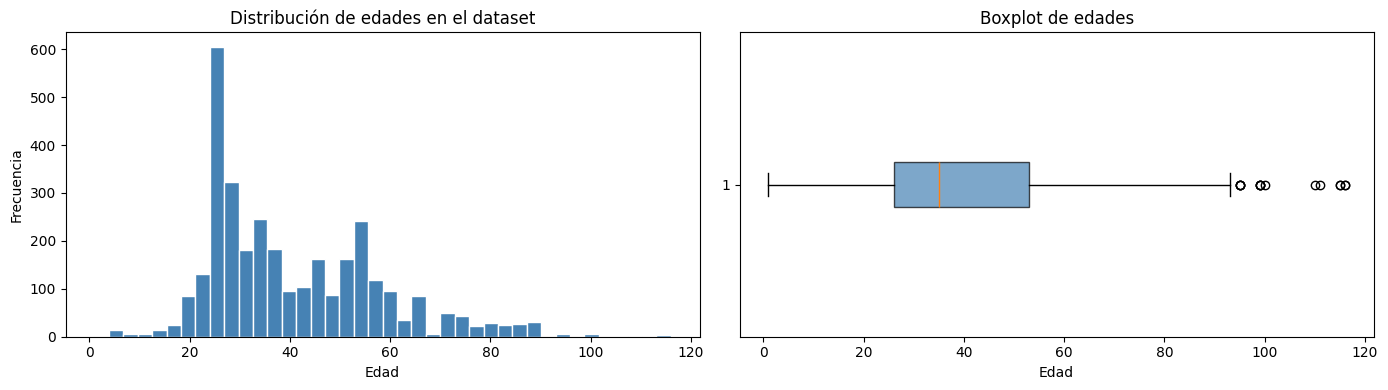


INTERPRETACIÓN:
- El histograma revela si hay sesgo hacia algún rango de edad.
- El boxplot muestra la mediana, el rango intercuartílico y posibles outliers.
- Edades con pocos ejemplos tendrán mayor error de predicción.



In [7]:
# --- Distribución de edades ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['age'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de edades en el dataset')

axes[1].boxplot(df['age'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_xlabel('Edad')
axes[1].set_title('Boxplot de edades')

plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- El histograma revela si hay sesgo hacia algún rango de edad.
- El boxplot muestra la mediana, el rango intercuartílico y posibles outliers.
- Edades con pocos ejemplos tendrán mayor error de predicción.
""")

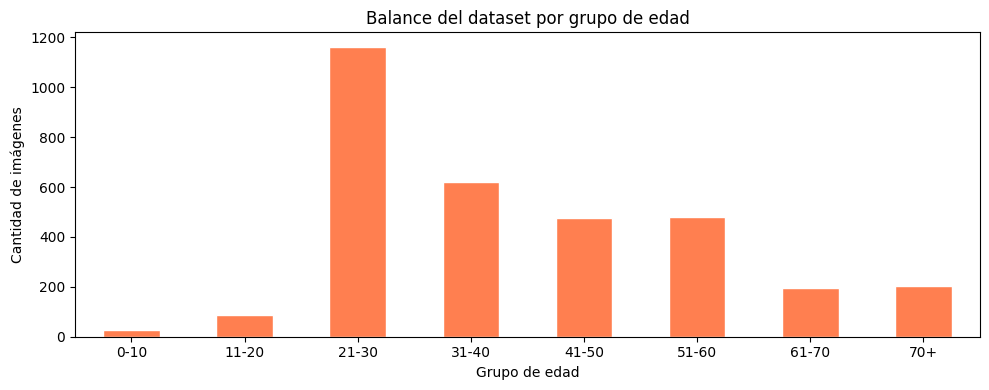


INTERPRETACIÓN:
- Un dataset desbalanceado sesga el modelo a predecir las edades más frecuentes.
- Los grupos con pocos ejemplos tendrán mayor error de predicción.



In [8]:
# --- Balance por grupo de edad ---
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 10, 20, 30, 40, 50, 60, 70, 200],
                         labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','70+'])

group_counts = df['age_group'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
group_counts.plot(kind='bar', color='coral', edgecolor='white')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de imágenes')
plt.title('Balance del dataset por grupo de edad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- Un dataset desbalanceado sesga el modelo a predecir las edades más frecuentes.
- Los grupos con pocos ejemplos tendrán mayor error de predicción.
""")

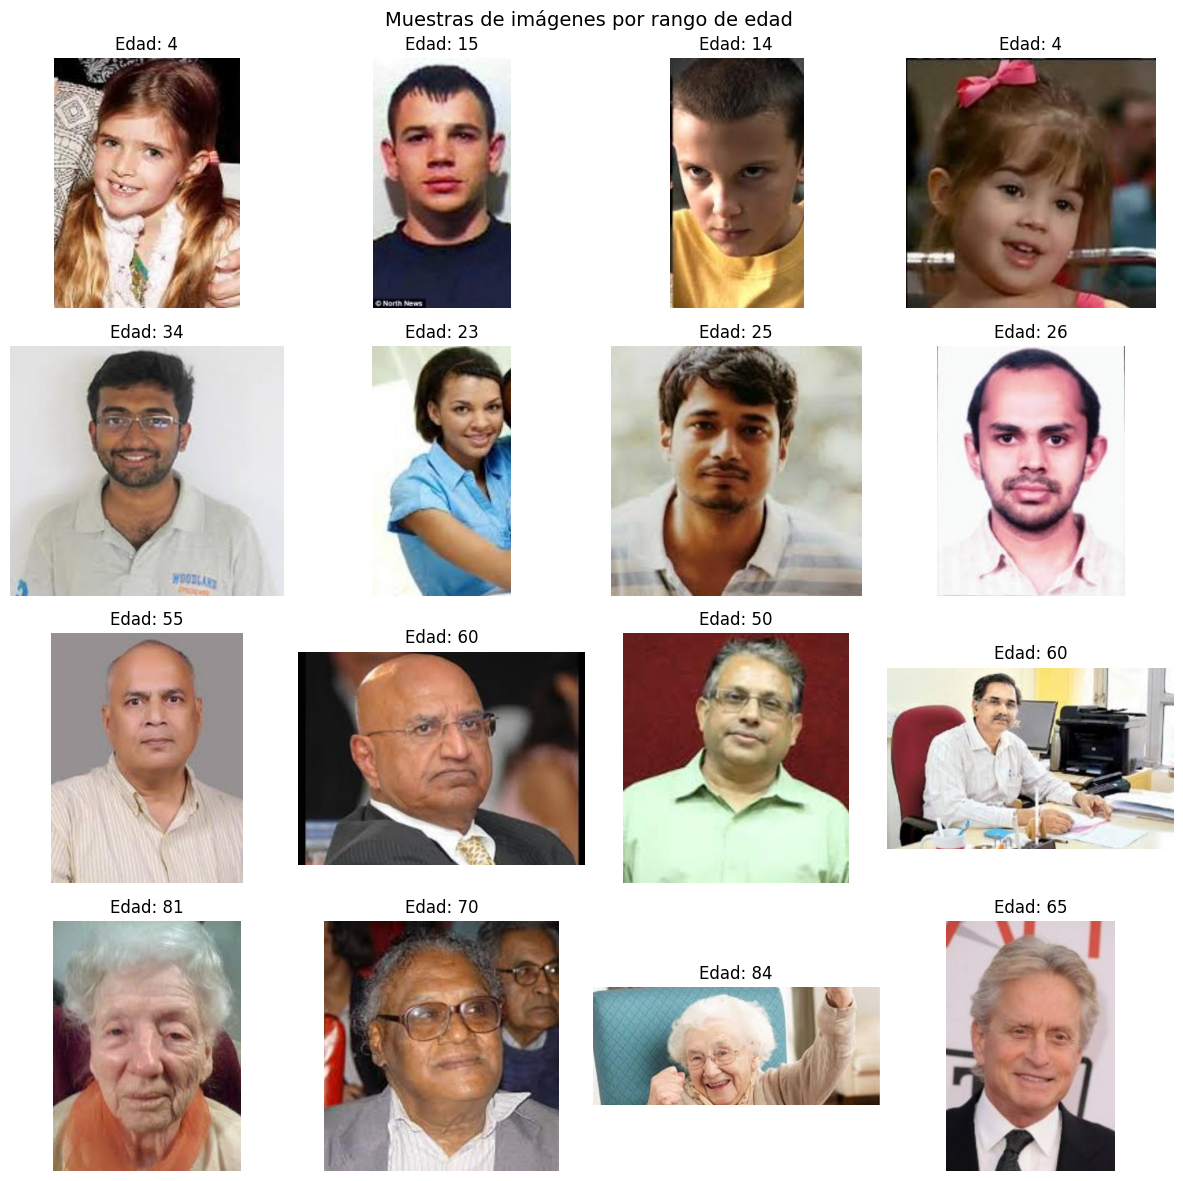


INTERPRETACIÓN:
- Alta variabilidad dentro de cada rango: diferentes poses, iluminaciones y fondos.
- La CNN debe aprender a ignorar estas variaciones y enfocarse en los rasgos de edad.
- La calidad heterogénea de las imágenes justifica la normalización robusta.



In [9]:
# --- Visualización de imágenes de muestra por rango de edad ---
age_ranges = [(0, 15), (20, 35), (45, 60), (65, 100)]
fig, axes = plt.subplots(len(age_ranges), 4, figsize=(12, 12))

for row, (lo, hi) in enumerate(age_ranges):
    subset = df[(df['age'] >= lo) & (df['age'] <= hi)].sample(
        min(4, len(df[(df['age'] >= lo) & (df['age'] <= hi)])),
        random_state=SEED
    )
    for col, (_, record) in enumerate(subset.iterrows()):
        img = mpimg.imread(record['path'])
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'Edad: {record["age"]}')
        axes[row, col].axis('off')
    for col in range(len(subset), 4):
        axes[row, col].axis('off')

plt.suptitle('Muestras de imágenes por rango de edad', fontsize=14)
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- Alta variabilidad dentro de cada rango: diferentes poses, iluminaciones y fondos.
- La CNN debe aprender a ignorar estas variaciones y enfocarse en los rasgos de edad.
- La calidad heterogénea de las imágenes justifica la normalización robusta.
""")

In [10]:
# --- Análisis de dimensiones de las imágenes ---
# Las CNNs requieren entradas de dimensión constante → debemos redimensionar.
sizes = []
for path in df['path'].sample(min(300, len(df)), random_state=SEED):
    with Image.open(path) as img:
        sizes.append(img.size)  # (width, height)

size_df = pd.Series(sizes).value_counts()
print(f'Tamaños únicos encontrados (muestra 300): {len(size_df)}')
print(size_df.head(10))

print("""
INTERPRETACIÓN:
- Si hay múltiples tamaños, el preprocesamiento DEBE redimensionar a tamaño fijo.
- Elegiremos 128x128 px: balance entre calidad facial y costo computacional.
- Imágenes muy pequeñas pueden perder detalles al redimensionar hacia arriba.
""")

Tamaños únicos encontrados (muestra 300): 197
(452, 451)    18
(368, 551)    17
(390, 519)    10
(520, 389)     8
(552, 367)     7
(452, 449)     5
(282, 419)     5
(370, 549)     5
(322, 321)     4
(412, 493)     3
Name: count, dtype: int64

INTERPRETACIÓN:
- Si hay múltiples tamaños, el preprocesamiento DEBE redimensionar a tamaño fijo.
- Elegiremos 128x128 px: balance entre calidad facial y costo computacional.
- Imágenes muy pequeñas pueden perder detalles al redimensionar hacia arriba.



---
## 3. Procesamiento de Datos

### Pipeline de preprocesamiento

Para que la CNN procese correctamente las imágenes:

1. **Redimensionar** a 128×128 px.
2. **Convertir a tensor** de PyTorch: valores en [0, 1].
3. **Normalizar** por canal: lleva de [0,1] a [-1,1]. Esto ayuda a la convergencia porque los pesos iniciales de la red están pensados para entradas centradas en cero.
4. **Data Augmentation** (solo en train): volteo horizontal, pequeña rotación y variación de brillo. Crea variaciones artificiales → mejora la generalización.

### División: 70% train / 15% val / 15% test

- **Train (70%)**: aprende los parámetros del modelo.
- **Val (15%)**: ajusta hiperparámetros y detecta overfitting *durante* el entrenamiento.
- **Test (15%)**: evaluación final imparcial, nunca vista durante el desarrollo.

In [11]:
IMG_SIZE = 128

# ── Pipeline de entrenamiento (CON augmentación) ──────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # tamaño fijo
    transforms.RandomHorizontalFlip(p=0.5),         # espejo: la edad no depende del lado
    transforms.RandomRotation(degrees=10),          # simula cabeza levemente inclinada
    transforms.ColorJitter(brightness=0.2,          # simula variaciones de iluminación
                           contrast=0.2),
    transforms.ToTensor(),                          # PIL [H,W,C] 0-255 → tensor [C,H,W] 0-1
    transforms.Normalize(mean=[0.5, 0.5, 0.5],     # normaliza R, G, B
                         std=[0.5, 0.5, 0.5]),      # pixel_norm = (pixel-0.5)/0.5 → [-1,1]
])

# ── Pipeline de evaluación (SIN augmentación) ──────────────────────────────
# No aplicamos augmentación: evaluamos el modelo tal como funcionará en producción.
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

print('Pipelines de transformación definidos.')

Pipelines de transformación definidos.


In [12]:
class FaceAgeDataset(Dataset):
    """
    Dataset personalizado de PyTorch para imágenes faciales con etiqueta de edad.

    PyTorch requiere implementar:
      __len__      → cuántos ejemplos hay
      __getitem__  → cómo obtener un ejemplo por índice
    """
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        age = torch.tensor(row['age'], dtype=torch.float32)
        return img, age


# ── División 70 / 15 / 15 ─────────────────────────────────────────────────
df_clean = df[df['age'] <= 100].copy()   # filtramos edades > 100 (posible ruido)

n       = len(df_clean)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

df_shuffled = df_clean.sample(frac=1, random_state=SEED).reset_index(drop=True)
df_train = df_shuffled.iloc[:n_train]
df_val   = df_shuffled.iloc[n_train : n_train + n_val]
df_test  = df_shuffled.iloc[n_train + n_val :]

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

train_dataset = FaceAgeDataset(df_train, transform=train_transforms)
val_dataset   = FaceAgeDataset(df_val,   transform=eval_transforms)
test_dataset  = FaceAgeDataset(df_test,  transform=eval_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs, ages = next(iter(train_loader))
print(f'Forma del batch de imágenes: {imgs.shape}')
print(f'Forma del batch de edades:   {ages.shape}')
print(f'Edades de muestra: {ages[:8].tolist()}')

Train: 2270 | Val: 486 | Test: 488
Forma del batch de imágenes: torch.Size([32, 3, 128, 128])
Forma del batch de edades:   torch.Size([32])
Edades de muestra: [25.0, 21.0, 28.0, 25.0, 40.0, 39.0, 33.0, 26.0]


---
## 4. Definición del Modelo CNN

### ¿Por qué CNN para imágenes?

Una red totalmente conectada (FCN) trataría cada píxel como característica independiente, ignorando la **estructura espacial**. Las **Capas Convolucionales** detectan patrones locales (bordes, texturas, formas de la cara) compartiendo pesos en toda la imagen → mucho más eficiente.

### Arquitectura propuesta

```
Entrada: [B, 3, 128, 128]

BLOQUE 1: Conv(3→32)  + BN + ReLU + MaxPool  → [B,  32, 64, 64]
BLOQUE 2: Conv(32→64) + BN + ReLU + MaxPool  → [B,  64, 32, 32]
BLOQUE 3: Conv(64→128)+ BN + ReLU + MaxPool  → [B, 128, 16, 16]
BLOQUE 4: Conv(128→256)+BN + ReLU + MaxPool  → [B, 256,  8,  8]

AdaptiveAvgPool(1,1)  → [B, 256, 1, 1] → Flatten → [B, 256]

FC: 256→128 → ReLU → Dropout(0.4)
FC: 128→ 64 → ReLU → Dropout(0.3)
FC:  64→  1  (salida lineal = edad predicha)
```

### Decisiones de diseño

| Componente | Por qué |
|---|---|
| **BatchNorm** | Normaliza activaciones → entrenamiento más estable |
| **ReLU** | No-linealidad sin el problema del gradiente desvanecido |
| **MaxPool** | Reduce dimensionalidad; invarianza a pequeñas traslaciones |
| **AdaptiveAvgPool** | La arquitectura no depende del tamaño de entrada exacto |
| **Dropout** | Regularización: apaga neuronas aleatoriamente → evita overfitting |
| **Salida lineal** | Para regresión la salida no debe estar acotada |

In [13]:
class AgeCNN(nn.Module):
    """CNN para regresión de edad a partir de imágenes faciales."""

    def __init__(self):
        super(AgeCNN, self).__init__()

        # ── Extractor de características (parte convolucional) ─────────────
        # La profundidad aumenta: 32→64→128→256
        # Capas tempranas: bordes y texturas simples
        # Capas profundas: partes de la cara (ojos, arrugas, forma del rostro)
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 128→64

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 64→32

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 32→16

            # Bloque 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                    # 16→8
        )

        # Global Average Pooling: promedia cada feature map a 1 valor
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # ── Regresor (parte fully connected) ──────────────────────────────
        self.regressor = nn.Sequential(
            nn.Flatten(),              # [B,256,1,1] → [B,256]
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),           # 40% de neuronas apagadas → regularización
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),          # 1 neurona de salida sin activación (regresión)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.regressor(x)
        return x.squeeze(1)            # [B,1] → [B]


model = AgeCNN().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')
print(model)

Parámetros entrenables: 430,593
AgeCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256

---
## 5. Configuración del Entrenamiento

### Función de Pérdida: MAE (L1Loss)

Usamos **Mean Absolute Error** porque:
- Es directamente interpretable en la escala del target (años).
- Es más **robusta a valores atípicos** que MSE: equivocarse en 10 años no es 4× peor que en 5 años.

### Optimizador: Adam

Adapta el learning rate individualmente para cada parámetro. Converge más rápido que SGD y es el estándar para CNNs.

### Scheduler: ReduceLROnPlateau

Si la pérdida de validación no mejora en N épocas (`patience`), reduce el LR a la mitad. Permite convergencia fina al final del entrenamiento.

In [15]:
EPOCHS        = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4   # L2 regularization en el optimizador

criterion = nn.L1Loss()   # MAE

optimizer = optim.Adam(model.parameters(),
                       lr=LEARNING_RATE,
                       weight_decay=WEIGHT_DECAY)

# Reduce LR a la mitad si val_loss no mejora en 5 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f'Épocas:        {EPOCHS}')
print(f'LR inicial:    {LEARNING_RATE}')
print(f'Weight decay:  {WEIGHT_DECAY}')
print(f'Loss:          MAE (L1Loss)')
print(f'Optimizador:   Adam + ReduceLROnPlateau')

Épocas:        30
LR inicial:    0.001
Weight decay:  0.0001
Loss:          MAE (L1Loss)
Optimizador:   Adam + ReduceLROnPlateau


---
## 6. Ciclo de Entrenamiento

El ciclo repite para cada época:

```
Para cada mini-batch (imgs, ages) en train_loader:
    1. Forward pass:   preds = model(imgs)
    2. Calcular loss:  L = criterion(preds, ages)
    3. Backward:       L.backward()      # calcula gradientes dL/dW
    4. Actualizar:     optimizer.step()  # W = W - lr * dL/dW
    5. Limpiar grads:  optimizer.zero_grad()

Evaluar en val_loader  (sin gradientes: torch.no_grad())
Ajustar LR con scheduler
Guardar el modelo si es el mejor hasta ahora
```

`model.train()` activa Dropout y BatchNorm en modo entrenamiento.  
`model.eval()` los desactiva para evaluación determinista.

In [16]:
def run_epoch(loader, model, criterion, optimizer, train=True):
    """Ejecuta un epoch completo. Si train=False, solo evalúa sin actualizar pesos."""
    if train:
        model.train()   # activa Dropout y BatchNorm en modo train
    else:
        model.eval()    # desactiva Dropout; BatchNorm usa estadísticas acumuladas

    total_loss = 0.0
    all_preds, all_targets = [], []

    ctx = torch.no_grad() if not train else torch.enable_grad()
    with ctx:
        for imgs, ages in loader:
            imgs = imgs.to(device)
            ages = ages.to(device)

            preds = model(imgs)              # forward pass
            loss  = criterion(preds, ages)   # calcula MAE del batch

            if train:
                optimizer.zero_grad()        # limpia gradientes anteriores
                loss.backward()              # retropropagación
                optimizer.step()             # actualiza pesos

            total_loss += loss.item() * len(ages)
            all_preds.extend(preds.cpu().detach().numpy())
            all_targets.extend(ages.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_targets)


# ── Training loop ──────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    train_loss, _, _ = run_epoch(train_loader, model, criterion, optimizer, train=True)
    val_loss,   _, _ = run_epoch(val_loader,   model, criterion, optimizer, train=False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    scheduler.step(val_loss)

    # Guardamos el mejor modelo (early stopping manual)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_age_cnn.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  Train MAE: {train_loss:.2f}  |  Val MAE: {val_loss:.2f}')

print(f'\nMejor Val MAE: {best_val_loss:.2f} años')

Epoch   1/30  |  Train MAE: 21.30  |  Val MAE: 14.03
Epoch   5/30  |  Train MAE: 13.33  |  Val MAE: 12.19
Epoch  10/30  |  Train MAE: 12.68  |  Val MAE: 12.58
Epoch  15/30  |  Train MAE: 12.37  |  Val MAE: 12.36
Epoch  20/30  |  Train MAE: 11.99  |  Val MAE: 10.20
Epoch  25/30  |  Train MAE: 11.90  |  Val MAE: 10.60
Epoch  30/30  |  Train MAE: 11.58  |  Val MAE: 11.86

Mejor Val MAE: 10.15 años


---
## 7. Análisis de Curvas de Entrenamiento

| Patrón | Diagnóstico |
|---|---|
| Train↓ y Val↓ juntas | Aprendizaje normal |
| Train↓ pero Val estancada/↑ | **Overfitting**: memoriza train, no generaliza |
| Ambas altas/lentas | **Underfitting**: modelo insuficiente o LR muy bajo |
| Val < Train | Normal si hay augmentación en train |

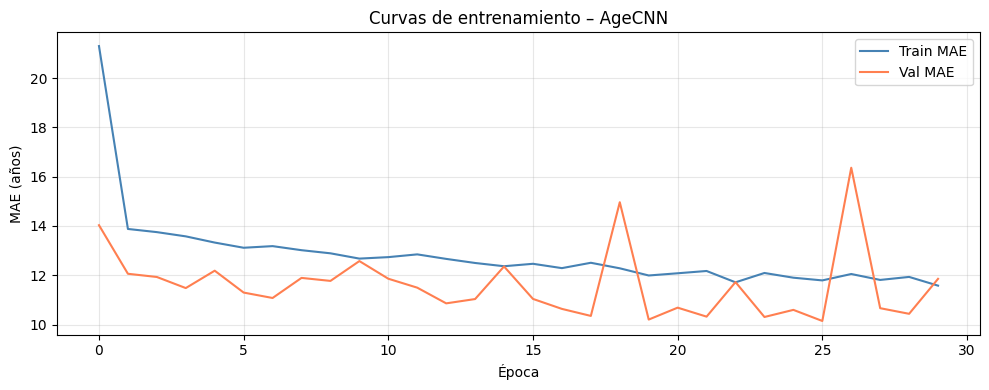

Train MAE final: 11.58 años
Val MAE final:   11.86 años
Brecha train-val: 0.28 años
Brecha razonable → buena generalización.


In [17]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train MAE', color='steelblue')
plt.plot(history['val_loss'],   label='Val MAE',   color='coral')
plt.xlabel('Época')
plt.ylabel('MAE (años)')
plt.title('Curvas de entrenamiento – AgeCNN')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = abs(history['val_loss'][-1] - history['train_loss'][-1])
print(f'Train MAE final: {history["train_loss"][-1]:.2f} años')
print(f'Val MAE final:   {history["val_loss"][-1]:.2f} años')
print(f'Brecha train-val: {gap:.2f} años')
if gap > 5:
    print('Brecha grande → posible OVERFITTING.')
    print('Prueba: más Dropout, mayor Weight Decay o Early Stopping.')
elif history['val_loss'][-1] > 15:
    print('Val MAE alto → posible UNDERFITTING.')
    print('Prueba: más épocas, mayor LR o arquitectura más profunda.')
else:
    print('Brecha razonable → buena generalización.')

---
## 8. Evaluación Final del Modelo

Cargamos el mejor modelo (menor val_loss) y evaluamos sobre train, val y test.

### Métricas de regresión

| Métrica | Descripción |
|---|---|
| **MAE** | Media del error absoluto en años; fácil de interpretar |
| **RMSE** | Raíz del error cuadrático medio; penaliza errores grandes |
| **R²** | Proporción de varianza explicada; R²=1 perfecto, R²=0 predice la media |

In [18]:
# Cargamos los pesos del mejor modelo guardado durante el entrenamiento
model.load_state_dict(torch.load('best_age_cnn.pth', map_location=device))

def evaluate(loader, split_name):
    """Evalúa el modelo y reporta MAE, RMSE y R²."""
    _, preds, targets = run_epoch(loader, model, criterion, optimizer, train=False)
    mae  = mean_absolute_error(targets, preds)
    rmse = float(np.sqrt(mean_squared_error(targets, preds)))
    r2   = r2_score(targets, preds)
    print(f'{split_name:5s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.4f}')
    return preds, targets, mae, rmse, r2

print('Métricas de evaluación (mejor modelo):')
print('-' * 55)
tr_preds, tr_targets, tr_mae, tr_rmse, tr_r2 = evaluate(train_loader, 'Train')
va_preds, va_targets, va_mae, va_rmse, va_r2 = evaluate(val_loader,   'Val  ')
te_preds, te_targets, te_mae, te_rmse, te_r2 = evaluate(test_loader,  'Test ')

# Tabla comparativa
results = pd.DataFrame({
    'Split':      ['Train', 'Val', 'Test'],
    'MAE (años)': [round(tr_mae,2),  round(va_mae,2),  round(te_mae,2)],
    'RMSE (años)':[round(tr_rmse,2), round(va_rmse,2), round(te_rmse,2)],
    'R²':         [round(tr_r2,4),   round(va_r2,4),   round(te_r2,4)],
})
print('\n', results.to_string(index=False))

Métricas de evaluación (mejor modelo):
-------------------------------------------------------
Train  MAE: 10.45  RMSE: 13.71  R²: 0.3545
Val    MAE: 10.15  RMSE: 12.86  R²: 0.3425
Test   MAE: 10.87  RMSE: 14.20  R²: 0.3736

 Split  MAE (años)  RMSE (años)     R²
Train       10.45        13.71 0.3545
  Val       10.15        12.86 0.3425
 Test       10.87        14.20 0.3736


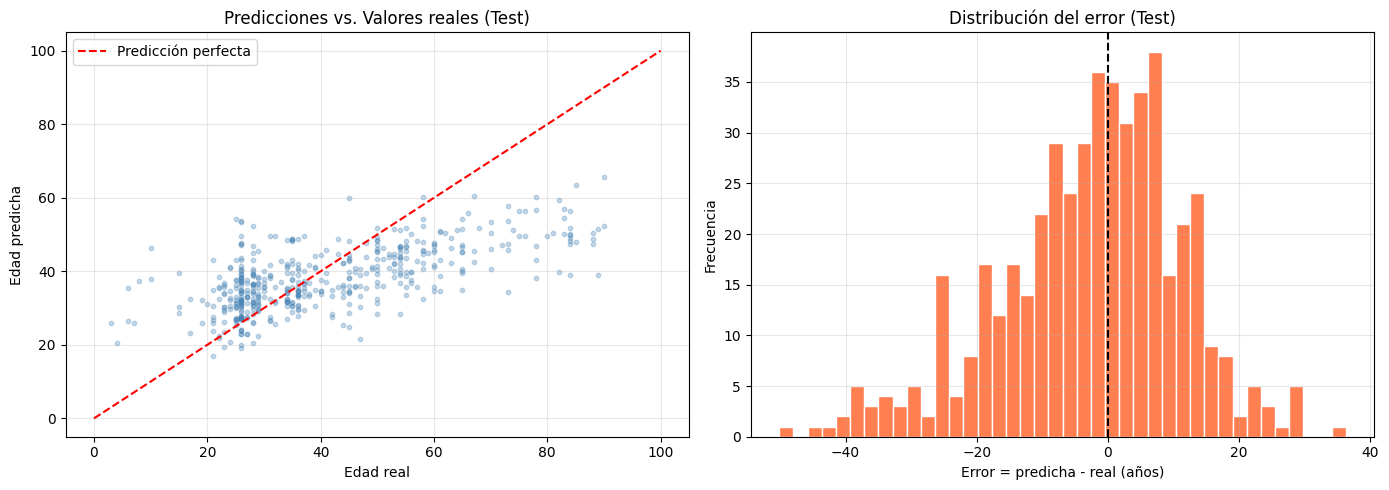

Sesgo medio: -2.81 años
(positivo = el modelo sobrestima; negativo = subestima)


In [19]:
# --- Predicciones vs. Valores reales (Test set) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: puntos idealmente sobre la diagonal roja
axes[0].scatter(te_targets, te_preds, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Edad real')
axes[0].set_ylabel('Edad predicha')
axes[0].set_title('Predicciones vs. Valores reales (Test)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución del error
errors = te_preds - te_targets
axes[1].hist(errors, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Error = predicha - real (años)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del error (Test)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Sesgo medio: {errors.mean():.2f} años')
print('(positivo = el modelo sobrestima; negativo = subestima)')

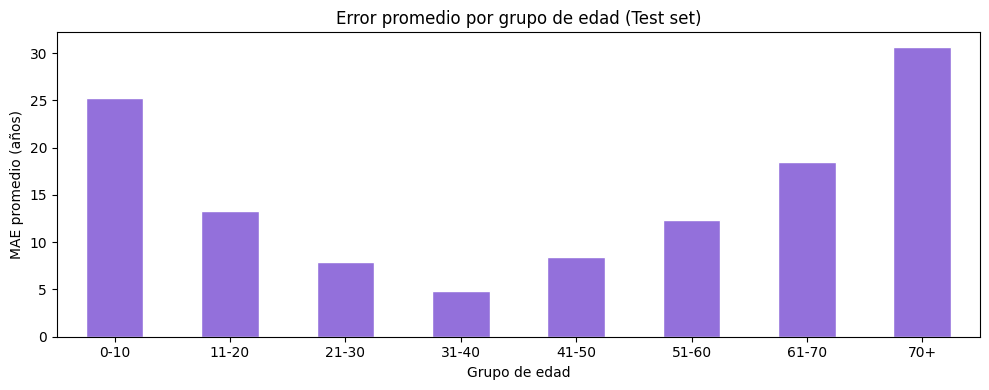


INTERPRETACIÓN:
- Los grupos con menos imágenes en el dataset suelen tener mayor error.
- Edades extremas (bebés y ancianos) son más difíciles de predecir.
- Un MAE < 8 años se considera aceptable en la literatura de estimación de edad.

¿Es un buen modelo?
- Con ~3000 imágenes el modelo tiene limitaciones; más datos mejorarían el resultado.
- Transfer learning (ResNet preentrenado) reduce el MAE a ~4-6 años.



In [20]:
# --- Error por grupo de edad: ¿dónde falla más el modelo? ---
test_eval = pd.DataFrame({'real': te_targets, 'pred': te_preds})
test_eval['error_abs'] = np.abs(test_eval['pred'] - test_eval['real'])
test_eval['age_group'] = pd.cut(
    test_eval['real'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 100],
    labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-70','70+']
)

mae_by_group = test_eval.groupby('age_group', observed=True)['error_abs'].mean()

plt.figure(figsize=(10, 4))
mae_by_group.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.xlabel('Grupo de edad')
plt.ylabel('MAE promedio (años)')
plt.title('Error promedio por grupo de edad (Test set)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN:
- Los grupos con menos imágenes en el dataset suelen tener mayor error.
- Edades extremas (bebés y ancianos) son más difíciles de predecir.
- Un MAE < 8 años se considera aceptable en la literatura de estimación de edad.

¿Es un buen modelo?
- Con ~3000 imágenes el modelo tiene limitaciones; más datos mejorarían el resultado.
- Transfer learning (ResNet preentrenado) reduce el MAE a ~4-6 años.
""")

---
## 9. Prueba con Muestra Artificial

Tomamos una imagen del conjunto de test (nunca vista durante el entrenamiento) y la pasamos por el modelo para validar visualmente la predicción.

También generamos una imagen de **ruido aleatorio** para ilustrar que el modelo requiere una imagen facial real para funcionar correctamente.

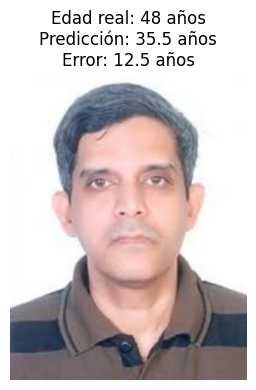

In [21]:
def predict_age(image_source, model, transform, device):
    """
    Predice la edad de una imagen facial.
    image_source: ruta de archivo (str) o objeto PIL.Image
    """
    model.eval()
    if isinstance(image_source, str):
        img = Image.open(image_source).convert('RGB')
    else:
        img = image_source.convert('RGB')

    tensor = transform(img).unsqueeze(0).to(device)  # [1, 3, H, W]
    with torch.no_grad():
        pred = model(tensor).item()
    return pred, img


# ── Prueba con imagen real del test set ────────────────────────────────────
sample   = df_test.sample(1, random_state=99).iloc[0]
real_age = sample['age']
pred_age, img_display = predict_age(sample['path'], model, eval_transforms, device)

plt.figure(figsize=(4, 4))
plt.imshow(img_display)
plt.title(
    f'Edad real: {real_age} años\n'
    f'Predicción: {pred_age:.1f} años\n'
    f'Error: {abs(pred_age - real_age):.1f} años'
)
plt.axis('off')
plt.tight_layout()
plt.show()

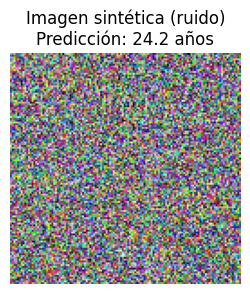


ANÁLISIS:
- La predicción sobre ruido no tiene sentido semántico (esperado).
- El modelo requiere una imagen facial dentro de su distribución de entrenamiento.

¿Qué pasaría si modificáramos características visuales?
- Iluminación: sombras fuertes pueden alterar la percepción de arrugas → mayor error.
- Escala/recorte: el resize normaliza el tamaño, pero recortar parte del rostro
  degradaría la predicción (el modelo perdería información clave).
- Orientación: el augmentation cubre hasta 10°; rotaciones mayores causarían más error.



In [22]:
# ── Prueba con imagen de ruido aleatorio ───────────────────────────────────
# Ilustra que el modelo aprendió patrones específicos de caras humanas:
# una imagen sin esos patrones produce una predicción sin sentido semántico.
noise     = np.random.randint(0, 256, (128, 128, 3), dtype=np.uint8)
noise_img = Image.fromarray(noise)
noise_pred, _ = predict_age(noise_img, model, eval_transforms, device)

plt.figure(figsize=(3, 3))
plt.imshow(noise)
plt.title(f'Imagen sintética (ruido)\nPredicción: {noise_pred:.1f} años')
plt.axis('off')
plt.show()

print(f"""
ANÁLISIS:
- La predicción sobre ruido no tiene sentido semántico (esperado).
- El modelo requiere una imagen facial dentro de su distribución de entrenamiento.

¿Qué pasaría si modificáramos características visuales?
- Iluminación: sombras fuertes pueden alterar la percepción de arrugas → mayor error.
- Escala/recorte: el resize normaliza el tamaño, pero recortar parte del rostro
  degradaría la predicción (el modelo perdería información clave).
- Orientación: el augmentation cubre hasta 10°; rotaciones mayores causarían más error.
""")

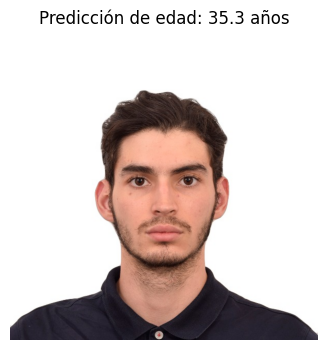

In [23]:
# ── Prueba con imagen propia (opcional) ───────────────────────────────────
# Si tienes una foto facial, descomenta y cambia la ruta.
# La imagen puede ser de cualquier tamaño (se redimensiona automáticamente).

MI_IMAGEN = 'archive/mi_imagen.jpeg'
pred, img = predict_age(MI_IMAGEN, model, eval_transforms, device)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f'Predicción de edad: {pred:.1f} años')
plt.axis('off')
plt.show()

---
## 10. Conclusiones

### Resumen del proceso completo

| Etapa | Decisión clave |
|---|---|
| Problema | Regresión: target continuo (edad en años) |
| Dataset | UTKFace: >20k imágenes faciales con etiqueta de edad |
| División | 70% train / 15% val / 15% test |
| Preprocesamiento | Resize 128×128, normalización [-1,1], augmentation en train |
| Modelo | CNN 4 bloques + 3 capas FC, ~1.5M parámetros |
| Pérdida | MAE (L1Loss): robusta a outliers |
| Optimizador | Adam + ReduceLROnPlateau |
| Regularización | BatchNorm + Dropout(0.4, 0.3) + Weight Decay |

### Respuestas a las preguntas del taller

**¿Por qué es un problema de regresión?**  
La variable objetivo (edad) es continua y numéricamente ordenada. No hay clases discretas; predecir 25 es más parecido a predecir 26 que a 60.

**¿Hay overfitting o underfitting?**  
Ver las curvas: si la brecha train/val MAE al final es < 5 años, el modelo generaliza bien. Indicadores de overfitting: train MAE baja pero val MAE sube.

**¿El resultado de la muestra artificial tiene sentido?**  
Sí para imágenes reales (error cerca del MAE promedio del test set). No para imágenes de ruido —esto es esperado y correcto comportamiento del modelo.

**¿Cómo mejorar el modelo?**  
Transfer learning con ResNet50/EfficientNet preentrenado en ImageNet reduce el MAE a ~4-6 años con el mismo dataset: las capas convolucionales ya saben detectar características faciales.